In [1]:
from lib.contact_settings import *
from lib.contact_wheel_rail import wheel, rail
from lib.contact_dyn_state import dynamic_state
from lib.contact_solver import patch_search
from lib.contact_material import material
from lib.contact_methods import eqv_el_normal_contact, kik_pyo_normal_contact
import matplotlib.pyplot as plt

In [2]:
Wheel_1 = wheel(lr=LEFT)
Wheel_2 = wheel()
Rai_1 = rail(lr=LEFT)
Rai_2 = rail()

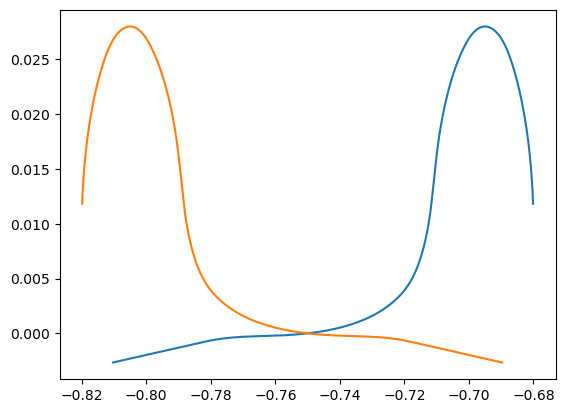

In [3]:
fig, ax = plt.subplots()
ax.plot(Wheel_1.wheel_start_pos[:, 0], Wheel_1.wheel_start_pos[:, 1])
ax.plot(Wheel_2.wheel_start_pos[:, 0] - 0.75 * 2, Wheel_2.wheel_start_pos[:, 1])

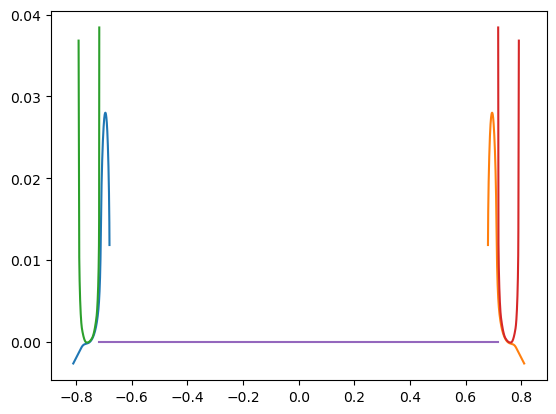

In [4]:
fig, ax = plt.subplots()
ax.plot(Wheel_1.wheel_start_pos[:, 0], Wheel_1.wheel_start_pos[:, 1])
ax.plot(Wheel_2.wheel_start_pos[:, 0], Wheel_2.wheel_start_pos[:, 1])
ax.plot(Rai_1.rail_start_pos[:, 0], Rai_1.rail_start_pos[:, 1])
ax.plot(Rai_2.rail_start_pos[:, 0], Rai_2.rail_start_pos[:, 1])
ax.plot([-Rai_1.gauge / 2, Rai_1.gauge / 2], [0, 0])

In [5]:
# new_state = dynamic_state(state_yaw=3*np.pi/180)
# new_state = dynamic_state(state_y=0, state_yaw=3*np.pi/180)
new_state = dynamic_state()

print(new_state.state_y)

0


In [6]:
Wheel_dyn_0 = wheel(lr=RIGHT)
Wheel_dyn_1 = wheel(lr=LEFT)

# Need check thge left wheel because it gives wierd results

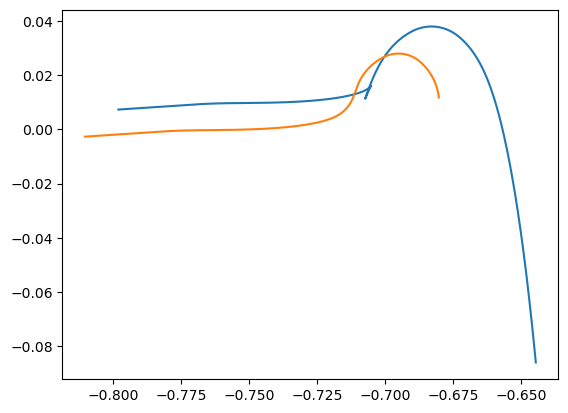

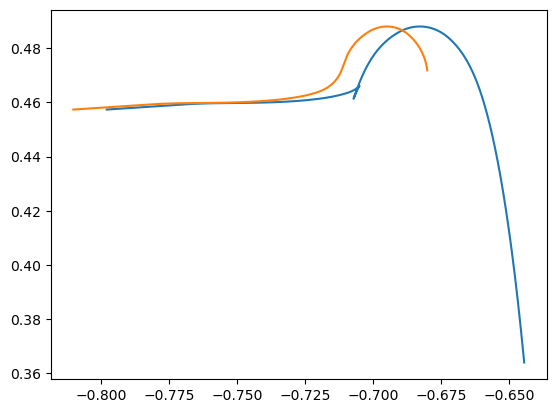

In [7]:
# new_state = dynamic_state(state_y=0, state_yaw=0)
new_state.state_yaw = 1.5 * 3 * np.pi / 180
new_state.state_y = 0.01
new_state.state_z = 0.01
Wheel_dyn_1.set_dynamic_state(new_state)
Wheel_dyn_1.calculate_position()

fig, ax = plt.subplots()
ax.plot(Wheel_dyn_1.wheel_profile_pos[:, 0], Wheel_dyn_1.wheel_profile_pos[:, 1])
ax.plot(Wheel_dyn_1.wheel_start_pos[:, 0], Wheel_dyn_1.wheel_start_pos[:, 1])

fig, ax = plt.subplots()
ax.plot(Wheel_dyn_1.wheel_radius[:, 0], Wheel_dyn_1.wheel_radius[:, 1])
# ax.plot(Wheel_dyn_1.wheel_profile_pos[:,0], Wheel_dyn_1.wheel_profile_pos[:,1])
ax.plot(Wheel_dyn_1.wheel_start_radius[:, 0], Wheel_dyn_1.wheel_start_radius[:, 1])

In [8]:
Wheel_1 = wheel(lr=LEFT)
Wheel_2 = wheel()
Rai_1 = rail(lr=LEFT)
Rai_2 = rail()

material_model = material()
contact_patches = [
    eqv_el_normal_contact(),
    eqv_el_normal_contact(),
    eqv_el_normal_contact(),
]

new_state = dynamic_state(state_z=0.0001)
Wheel_1.set_dynamic_state(new_state)
Wheel_1.calculate_position()

patch_search(Wheel_1, Rai_1, material_model, contact_patches)

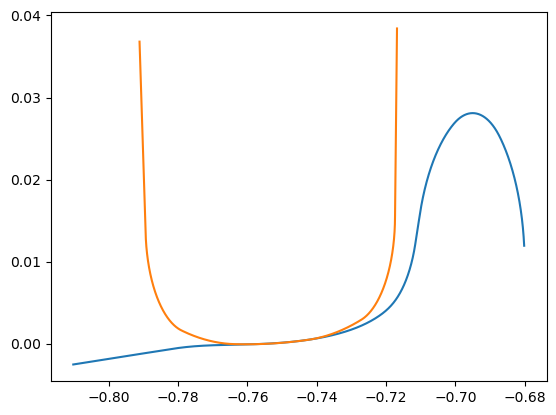

In [9]:
fig, ax = plt.subplots()
ax.plot(Wheel_1.wheel_profile_pos[:, 0], Wheel_1.wheel_profile_pos[:, 1])
ax.plot(Rai_1.rail_profile_pos[:, 0], Rai_1.rail_profile_pos[:, 1])

In [10]:
from calc_routines.determine_static_contact import static_contact

In [11]:
dy = 0.05e-3
deltays = np.arange(-20e-3, 20e-3 + dy, dy)
# deltays = np.array([0])

Wheel = wheel(lr=RIGHT)
Rail = rail(rail_inclination=20, lr=RIGHT)

material_model = material()

contact_model = eqv_el_normal_contact()
# contact_model = kik_pyo_normal_contact()

n_patches = 3

# contact_patches_eq = [eqv_el_normal_contact() for _ in range(n_patches)]
# contact_patches_kik = [kik_pyo_normal_contact() for _ in range(n_patches)]
contact_patches_eq = [
    eqv_el_normal_contact(),
    eqv_el_normal_contact(),
    eqv_el_normal_contact(),
]

contact_patches = [
    kik_pyo_normal_contact(),
    kik_pyo_normal_contact(),
    kik_pyo_normal_contact(),
]

In [12]:
patches_per_deltays, result_state_pressure = static_contact(
    deltays, Wheel, Rail, contact_patches, material_model
)

  7%|▋         | 53/801 [00:01<00:21, 34.74it/s]c:\Users\rocco\Desktop\PPP\prove\gitRepo\SimRail\calc_routines\determine_static_contact.py:87: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(
 16%|█▌        | 129/801 [00:04<00:22, 30.51it/s]c:\Users\rocco\Desktop\PPP\prove\gitRepo\SimRail\lib\contact_solver.py:113: RuntimeWarning: invalid value encountered in sqrt
  search_matrix_1[jj, valid_x] = np.sqrt(
c:\Users\rocco\Desktop\PPP\prove\gitRepo\SimRail\calc_routines\determine_static_contact.py:105: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(
 19%|█▉        | 156/801 [00:05<00:22, 28.51it/s]c:\Users\rocco\Desktop\PPP\prove\gitRepo\SimRail\calc_routines\determine_static_contact.py:87: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian

In [13]:
patches_per_deltays_eq, result_state_pressure_eq = static_contact(
    deltays, Wheel, Rail, contact_patches_eq, material_model
)

  0%|          | 0/801 [00:00<?, ?it/s]

100%|██████████| 801/801 [00:24<00:00, 32.78it/s]


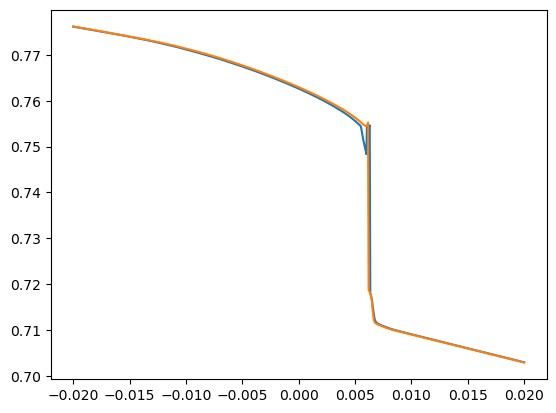

In [14]:
# look at [Dz, N, Q, Y, delta, centroid]
id_plot = 5

fig, ax = plt.subplots()
ax.plot(deltays, patches_per_deltays["patch_0"][:, id_plot]-deltays)
# ax.plot(deltays, patches_per_deltays["patch_1"][:, id_plot])
# ax.plot(deltays, patches_per_deltays["patch_2"][:, id_plot])
ax.plot(deltays, patches_per_deltays_eq["patch_0"][:, id_plot]-deltays)
# ax.plot(deltays, patches_per_deltays_eq["patch_1"][:, id_plot])
# ax.plot(deltays, patches_per_deltays_eq["patch_2"][:, id_plot])

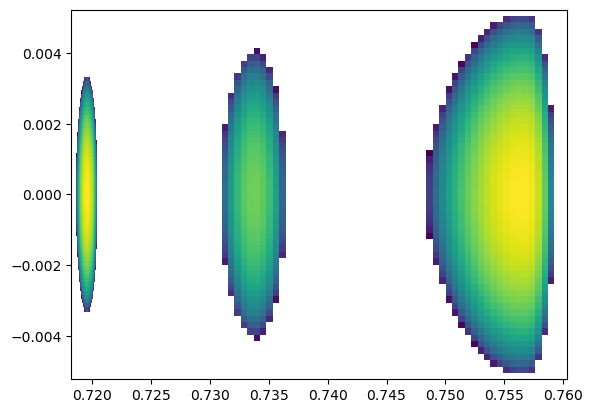

In [15]:
id_plot = 5
search_index = 520

fig, ax = plt.subplots()
for jj in range(3):

    Y, X = np.meshgrid(
        result_state_pressure[f"patch_{jj}"][
            58 * search_index : 58 * (search_index + 1), 1
        ],
        result_state_pressure[f"patch_{jj}"][
            58 * search_index : 58 * (search_index + 1), 0
        ],
    )

    if sum(sum(Y)):
        data_1 = np.transpose(
            result_state_pressure[f"patch_{jj}"][
                58 * search_index : 58 * (search_index + 1), 2:
            ]
        )
        data_1 = np.where(data_1 == 0, np.nan, data_1)
        ax.pcolormesh(
            Y
            + patches_per_deltays[f"patch_{jj}"][search_index, id_plot]
            - deltays[search_index],
            X,
            data_1,
        )

plt.show()

In [16]:
maxes_0 = []
mines_0 = []
maxes_1 = []
mines_1 = []
maxes_2 = []
mines_2 = []

for jj in range(len(deltays)):
    maxes_0.append(np.max(result_state_pressure["patch_0"][58 * jj:58 * (jj + 1), 2:]))
    mines_0.append(np.min(result_state_pressure["patch_0"][58 * jj:58 * (jj + 1), 2:]))
    maxes_1.append(np.max(result_state_pressure["patch_1"][58 * jj:58 * (jj + 1), 2:]))
    mines_1.append(np.min(result_state_pressure["patch_1"][58 * jj:58 * (jj + 1), 2:]))
    maxes_2.append(np.max(result_state_pressure["patch_2"][58 * jj:58 * (jj + 1), 2:]))
    mines_2.append(np.min(result_state_pressure["patch_2"][58 * jj:58 * (jj + 1), 2:]))


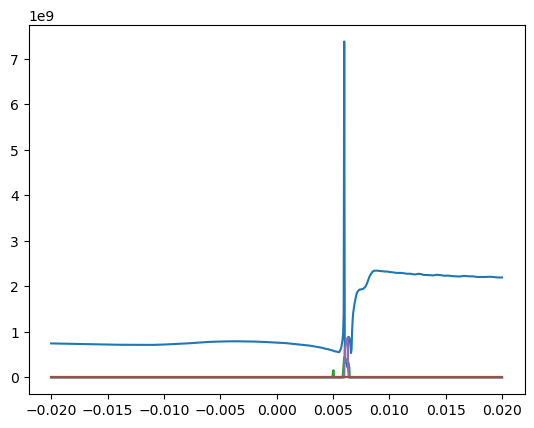

In [17]:
fig, ax = plt.subplots()
ax.plot(deltays, maxes_0)
ax.plot(deltays, mines_0)
ax.plot(deltays, maxes_1)
ax.plot(deltays, mines_1)
ax.plot(deltays, maxes_2)
ax.plot(deltays, mines_2)
plt.show()

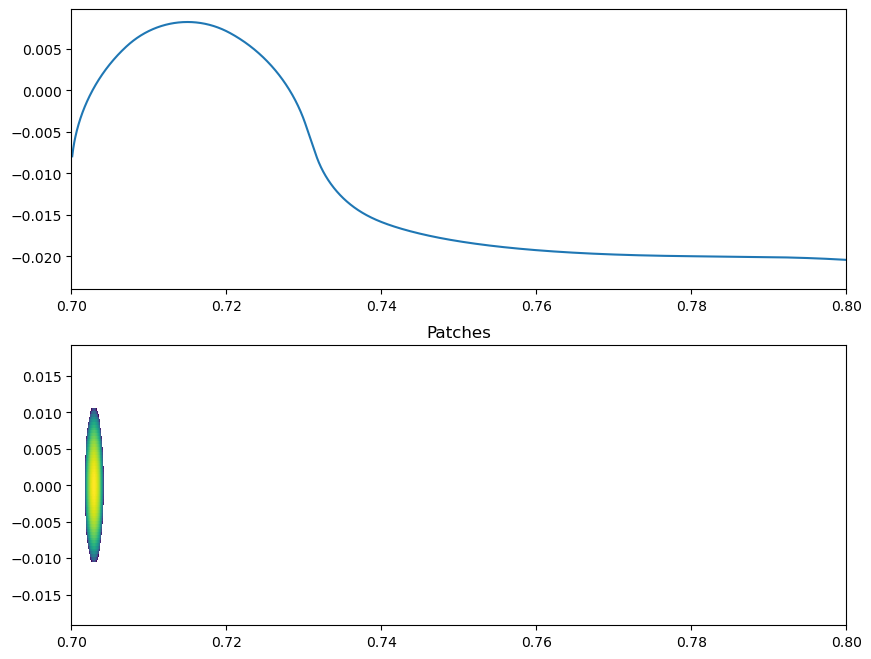

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Example data: a series of matrices
n_frames = len(deltays)  # Number of frames

# Set up the figure and axis
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))
ax[0].plot(Wheel.wheel_profile_pos[:, 0], Wheel.wheel_profile_pos[:, 1])
ax[0].set_xlim((0.7, 0.8))
ax[1].set_xlim((0.7, 0.8))
# ax[1].set_xlim(
#     np.min(result_state_pressure["patch_0"][:, 1])
#     + np.min(patches_per_deltays["patch_0"][:, id_plot] - deltays),
#     np.max(result_state_pressure["patch_0"][:, 1])
#     + np.max(patches_per_deltays["patch_0"][:, id_plot] - deltays),
# )
ax[1].set_ylim(
    np.min(result_state_pressure["patch_0"][:, 0]),
    np.max(result_state_pressure["patch_0"][:, 0]),
)

search_index = 0
id_plot = 5

pcolormesh_0 = None
pcolormesh_1 = None
pcolormesh_2 = None

for jj in range(3):

    Y, X = np.meshgrid(
        result_state_pressure[f"patch_{jj}"][
            58 * search_index : 58 * (search_index + 1), 1
        ],
        result_state_pressure[f"patch_{jj}"][
            58 * search_index : 58 * (search_index + 1), 0
        ],
    )

    data_1 = np.transpose(
        result_state_pressure[f"patch_{jj}"][
            58 * search_index : 58 * (search_index + 1), 2:
        ]
    )
    data_1 = np.where(data_1 == 0, np.nan, data_1)
    if jj == 0:
        pcolormesh_0 = ax[1].pcolormesh(
            Y
            + patches_per_deltays[f"patch_{jj}"][search_index, id_plot]
            - deltays[search_index],
            X,
            data_1,
        )
    elif jj == 1:
        pcolormesh_1 = ax[1].pcolormesh(
            Y
            + patches_per_deltays[f"patch_{jj}"][search_index, id_plot]
            - deltays[search_index],
            X,
            data_1,
        )
    elif jj == 2:
        pcolormesh_2 = ax[1].pcolormesh(
            Y
            + patches_per_deltays[f"patch_{jj}"][search_index, id_plot]
            - deltays[search_index],
            X,
            data_1,
        )
# fig.colorbar(pcolormesh, ax=ax)  # Optional: Add a colorbar
ax[1].set_title("Wheel")
ax[1].set_title("Patches")


# Update function for animation
def update(search_index):
    global pcolormesh_0, pcolormesh_1, pcolormesh_2

    for artist in [pcolormesh_0, pcolormesh_1, pcolormesh_2]:
        if artist:
            artist.remove()
    for jj in range(3):

        Y, X = np.meshgrid(
            result_state_pressure[f"patch_{jj}"][
                58 * search_index : 58 * (search_index + 1), 1
            ],
            result_state_pressure[f"patch_{jj}"][
                58 * search_index : 58 * (search_index + 1), 0
            ],
        )

        data_1 = np.transpose(
            result_state_pressure[f"patch_{jj}"][
                58 * search_index : 58 * (search_index + 1), 2:
            ]
        )
        data_1 = np.where(data_1 == 0, np.nan, data_1)
        if jj == 0:
            pcolormesh_0 = ax[1].pcolormesh(
                Y
                + patches_per_deltays[f"patch_{jj}"][search_index, id_plot]
                - deltays[search_index],
                X,
                data_1,
            )
        elif jj == 1:
            pcolormesh_1 = ax[1].pcolormesh(
                Y
                + patches_per_deltays[f"patch_{jj}"][search_index, id_plot]
                - deltays[search_index],
                X,
                data_1,
            )
        elif jj == 2:
            pcolormesh_2 = ax[1].pcolormesh(
                Y
                + patches_per_deltays[f"patch_{jj}"][search_index, id_plot]
                - deltays[search_index],
                X,
                data_1,
            )


# Create the animation
ani = FuncAnimation(fig, update, frames=n_frames, interval=200, blit=False)

# Save the animation as a .gif
gif_writer = PillowWriter(fps=24)  # Set frames per second (fps)
ani.save("matrix_animation.gif", writer=gif_writer)

# Display the animation (optional)
plt.show()